This notebook is used to check the heritability and disease relationships of the ICD Genetic Network

In [1]:

import obonet
import networkx as nx
import os
import sys
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import pickle as pk
import os.path
import pandas as pd
from collections import (defaultdict,Counter)
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
#Let's import the Genetic Heridatability Predictions from https://h2.cpr.ku.dk/icd10rglvl3.php

heritability_df = pd.read_csv("input/website_icd10_rg_lvl3.tsv", sep="\t")

In [3]:
#Let's create a dictionary where we extract the median genetic similarity between two diseases

ICD_heritability = {}
for i,v in heritability_df.iterrows():
    ICD_heritability[v['A'],v['B']] = v['X50_']
    


In [4]:
with open('output/allsources_icd_gene_dict_unified_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

In [5]:
doid_icd10_df = pd.read_csv("input/GDA/ICD10inDO.tsv", sep="\t")

In [6]:

icd10_do_name_dict = {}
icd10_do_doid_dict = {}

for i,v in doid_icd10_df.iterrows():
    icdterm = v['xrefs'].split(":")[1].split(".")[0]
    name = v['label'].split("@")[0]
    doid = v['id']
    if "," in icdterm:
        real_icd = icdterm.split(",")[0]
        icd10_do_name_dict[real_icd] = name
        icd10_do_doid_dict[real_icd] = doid
    else:
        icd10_do_name_dict[icdterm] = name
        icd10_do_doid_dict[icdterm] = doid

print(len(icd10_do_name_dict))
print(len(icd10_do_doid_dict))

867
867


In [7]:
icd10_do_doid_dict_rev = {}

for k,v in icd10_do_doid_dict.items():
    icd10_do_doid_dict_rev[v] = k

In [9]:
#Let's try to agglomerate diseases based on the disease ontology

#First
#Let's import the obo file for DOID 

url = 'https://raw.githubusercontent.com/DiseaseOntology/HumanDiseaseOntology/master/src/ontology/HumanDO.obo'
graph = obonet.read_obo(url)


In [32]:
       
#This function calculates the Jaccard Index between two lists
def overlap_jaccard(list1,list2):
    intersction_term= len(set(list1) & set(list2))
    denominator = len(set(list1).union(set(list2)))
    overlap_jaccard_coeff = intersction_term/denominator
    return overlap_jaccard_coeff

#This function is the first step for the resnik score calculation
def precalc_lower_bounds(G):
    """Pre-calculate the number of lower bounds of the graph nodes
    """
    G.lower_bounds = Counter()
    for n in G:
        G.lower_bounds[n] += 1
        for ans in nx.ancestors(G, n):
            G.lower_bounds[ans] += 1
   # G.descriptors.add("Pre-calculated lower bounds")
#This function is the second step for the resnik score calculation
def information_content(G, term):
    """Information content
    Args:
        G(Ontology Graph): Ontology graph object
        term(str): ontolgy term
    Returns:
        str - Information content
    Raises:
        PGSSLookupError: The term was not found in Ontology Graph
        PGSSInvalidOperation: see `pygosemsim.similarity.precalc_lower_bounds`
    """
    if term not in G.lower_bounds:
        raise exception.PGSSLookupError(f"Missing term: {term}")
    freq = G.lower_bounds[term] / len(G)
    return round(-1 * math.log2(freq), 3)

#This function is the third step for the resnik score calculation
def lowest_common_ancestor(G, term1, term2):
    """Naive implementation of lowest common ancestor (LCA)
    Args:
        G(GoGraph): Graph object
        term1(str): Ontology term 1
        term2(str): Ontology term 2
    Returns:
        str - Lowest common ancestor term
        or None if the terms have no common ancestors
    Raises:
        PGSSLookupError: The term was not found in Ontology Graph
        PGSSInvalidOperation: see `pygosemsim.similarity.precalc_lower_bounds`
    """
    if term1 not in G:
        raise exception.PGSSLookupError(f"Missing term: {term1}")
    if term2 not in G:
        raise exception.PGSSLookupError(f"Missing term: {term2}")
    lb1 = nx.ancestors(G, term1) | {term1}
    lb2 = nx.ancestors(G, term2) | {term2}
    common_ans = lb1 & lb2
    if not common_ans:
        return
    return min(common_ans, key=lambda x: G.lower_bounds[x])
import math
#This function would return the resnik score between two terms
def resnik(G, term1, term2):
    """Semantic similarity based on Resnik method
    Args:
        G(GoGraph): Ontology graph object
        term1(str): term 1
        term2(str): term 2
    Returns:
        float - Resnik similarity value (Information content of LCA)
        or None if the terms have no common ancestors
    Raises:
        PGSSLookupError: The term was not found in GoGraph
        PGSSInvalidOperation: see `pygosemsim.similarity.precalc_lower_bounds`
    """
    mica = lowest_common_ancestor(G, term1, term2)
    if mica is not None:
        return information_content(G, mica)
    



In [71]:
print(len(set(icd10_do_doid_dict_rev.values())&set(allsources_icd_gene_dict_unified.keys())))

743


In [80]:
G_down = nx.DiGraph.reverse(graph)

In [83]:

precalc_lower_bounds(G_down)

In [ ]:
pairwise_list = list(it.combinations(G_down.nodes(), 2))

In [ ]:
G_down_resnik = {}
for i,j in pairwise_list:
    G_down_resnik[i,j] = round(resnik(G_down, i, j),3)

In [ ]:
with open('output/G_down_resnik.pickle', 'wb') as handle:
    pk.dump(G_down_resnik, handle, protocol=pk.HIGHEST_PROTOCOL)

In [8]:
#with open('output/G_down_resnik.pickle', 'rb') as handle:
#    G_down_resnik = pk.load(handle)


with open('GenEpi large files/G_down_resnik.pickle', 'rb') as handle:
    G_down_resnik = pk.load(handle)

In [9]:
#Let's import the ICD Genetic network
G_gene_icd_disp_significant_post_df = pd.read_csv("output/G_gene_icd_disp_significant_post_df_v2026_official.tsv", sep="\t",index_col=0)
G_gene_icd_disp_significant_post = nx.from_pandas_edgelist(G_gene_icd_disp_significant_post_df, 'Dis A', 'Dis B')


In [10]:
#Let's select the resnik found in the edges of the ICD Genetic network and an equal number of disease pairs
#that are not in the ICD Genetic network

G_gene_icd_disp_significant_post_edges = list(G_gene_icd_disp_significant_post.edges())

G_gene_icd_disp_significant_post_edges_resnik_dict = {}
for e in G_gene_icd_disp_significant_post_edges:
    try:
        try:
            G_gene_icd_disp_significant_post_edges_resnik_dict[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]] = G_down_resnik[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]]
        except:
            G_gene_icd_disp_significant_post_edges_resnik_dict[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]] = G_down_resnik[icd10_do_doid_dict[e[1]],icd10_do_doid_dict[e[0]]]
    except:
        pass
            


In [11]:

dispair_no_genetic_network_list = []
for dis_pair in G_down_resnik.keys():
    if dis_pair not in G_gene_icd_disp_significant_post_edges_resnik_dict.keys():
        dispair_no_genetic_network_list.append(dis_pair)
        
random_equal_number = rd.sample(dispair_no_genetic_network_list,len(G_gene_icd_disp_significant_post_edges_resnik_dict))
random_resnik_equal_number = {}
for dispair in random_equal_number:
    random_resnik_equal_number[dispair] = G_down_resnik[dispair]


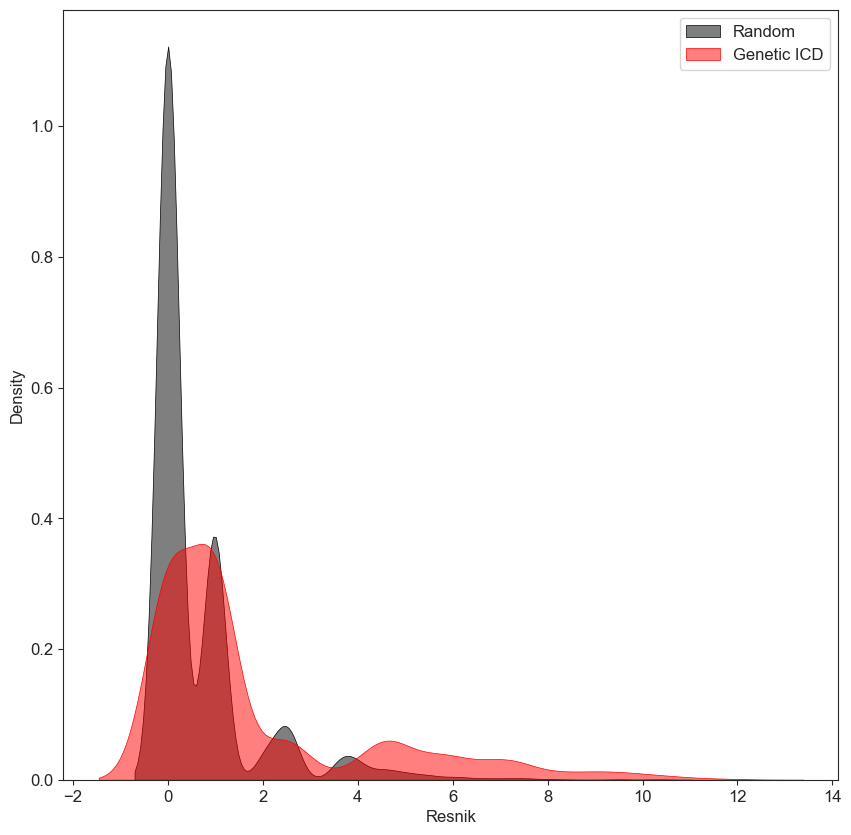

In [12]:
#Let's plot the distribution of all lcc z-scores

genetic_icd_resnik = [i for i in G_gene_icd_disp_significant_post_edges_resnik_dict.values() if str(i)!='nan']
random_resnik = [i for i in random_resnik_equal_number.values() if str(i)!='nan']

# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
sns.kdeplot(random_resnik,color='k',lw=.5,alpha=.5,fill=True,label='Random')
sns.kdeplot(genetic_icd_resnik,color='r',lw=.5,alpha=.5,fill=True,label='Genetic ICD')

plt.legend(loc='upper right',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('Resnik',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('Figures/Resnik_Comparison_Random_GeneticICD_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

In [56]:

# -----------------------------
# 2. Build Long-Format DataFrame
# -----------------------------
df_plot = pd.DataFrame({
    "Resnik": (
        genetic_icd_resnik +
        random_resnik 
    ),
    "Group": (
        ["mDDN"] * len(genetic_icd_resnik) +
        ["Random"] * len(random_resnik) 
    )
})

# Deterministic ordering
df_plot = df_plot.sort_values(["Group", "Resnik"]).reset_index(drop=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    df_plot.to_excel(writer, sheet_name="Fig2F", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [13]:
from scipy.stats import mannwhitneyu

# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(genetic_icd_resnik, random_resnik, alternative='two-sided')
result

MannwhitneyuResult(statistic=6783883.0, pvalue=5.516891016609002e-148)

In [14]:
np.median(genetic_icd_resnik)

0.978

In [15]:
np.median(random_resnik)

0.0

In [16]:
#Let's import the ICD partitions
with open('output/G_gene_icd_ICD_partition_v2026_official.pickle', 'rb') as handle:
    G_gene_icd_ICD_partition = pk.load(handle)

In [17]:
#Let's import the Louvain communities
with open('output/G_gene_icd_com_v2026_official.pickle', 'rb') as handle:
    G_gene_icd_com = pk.load(handle)

In [18]:
#Let's select all disease-pairs edges between the ICD disease categories

G_gene_icd_ICD_partition_edges = {}
for cat,dis_list in G_gene_icd_ICD_partition.items():
    dis_pairwise_list = list(it.combinations(dis_list, 2))
    dis_pairwise_list_edges = []
    for dis_pair in dis_pairwise_list:
        if (dis_pair[0],dis_pair[1]) in G_gene_icd_disp_significant_post_edges or (dis_pair[1],dis_pair[0]) in G_gene_icd_disp_significant_post_edges:
            dis_pairwise_list_edges.append(dis_pair)
    G_gene_icd_ICD_partition_edges[cat] = dis_pairwise_list_edges

G_gene_icd_com_edges = {}
for com,dis_list in G_gene_icd_com.items():
    dis_pairwise_list = list(it.combinations(dis_list, 2))
    dis_pairwise_list_edges = []
    for dis_pair in dis_pairwise_list:
        if (dis_pair[0],dis_pair[1]) in G_gene_icd_disp_significant_post_edges or (dis_pair[1],dis_pair[0]) in G_gene_icd_disp_significant_post_edges:
            dis_pairwise_list_edges.append(dis_pair)
    G_gene_icd_com_edges[com] = dis_pairwise_list_edges
    

In [19]:
#Let's extract the median resnik for each category
G_gene_icd_ICD_partition_edges_median_resnik = {}
for cat,edgelist in G_gene_icd_ICD_partition_edges.items():
    resnik_list = []
    for e in edgelist:
        try:
            try:
                resnik_list.append(G_down_resnik[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]])
            except:
                resnik_list.append(G_down_resnik[icd10_do_doid_dict[e[1]],icd10_do_doid_dict[e[0]]])
        except:
            pass
    resnik_list_cl = [i for i in resnik_list if str(i)!='nan']
    G_gene_icd_ICD_partition_edges_median_resnik[cat] = np.median(resnik_list_cl)

#Let's extract the median resnik for each category
G_gene_icd_com_edges_median_resnik = {}
for com,edgelist in G_gene_icd_com_edges.items():
    resnik_list = []
    for e in edgelist:
        try:
            try:
                resnik_list.append(G_down_resnik[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]])
            except:
                resnik_list.append(G_down_resnik[icd10_do_doid_dict[e[1]],icd10_do_doid_dict[e[0]]])
        except:
            pass
    resnik_list_cl = [i for i in resnik_list if str(i)!='nan']
    G_gene_icd_com_edges_median_resnik[com] = np.median(resnik_list_cl)
            

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [21]:
#Let's select 10,000 random resnik values

random_resnik_number = rd.sample(list(G_down_resnik.values()),10000)


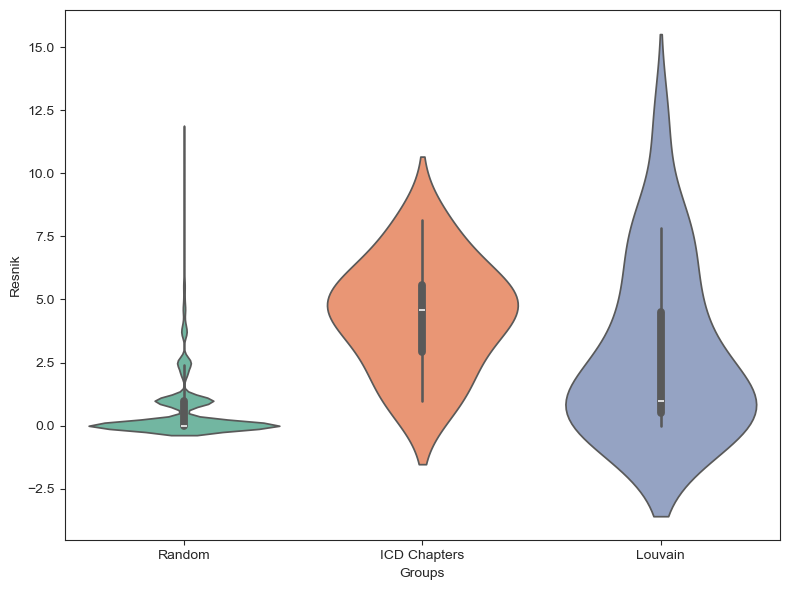

In [22]:
ICD_avg_resnik = [i for i in G_gene_icd_ICD_partition_edges_median_resnik.values() if str(i)!='nan']
Louvain_avg_resnik = [i for i in G_gene_icd_com_edges_median_resnik.values() if str(i)!='nan']

# Combine the data into a single structure for plotting
avg_resnik_plot = [random_resnik_number, ICD_avg_resnik, Louvain_avg_resnik]

# Create the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(data=avg_resnik_plot, palette="Set2")

# Customize the plot
plt.xticks([0, 1, 2], ['Random', 'ICD Chapters', 'Louvain'])  # X-axis labels
plt.ylabel('Resnik')
plt.xlabel('Groups')

# Show the plot
plt.tight_layout()
plt.savefig('Figures/Resnik_Comparison_Random_GeneticICD_Violin_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [57]:

ICD_avg_resnik = [
    i for i in G_gene_icd_ICD_partition_edges_median_resnik.values()
    if pd.notna(i)
]

Louvain_avg_resnik = [
    i for i in G_gene_icd_com_edges_median_resnik.values()
    if pd.notna(i)
]

Random_avg_resnik = [
    i for i in random_resnik_number
    if pd.notna(i)
]

# -----------------------------
# 2. Build long-format dataframe
# -----------------------------
df_plot = pd.DataFrame({
    "resnik_value": (
        Random_avg_resnik +
        ICD_avg_resnik +
        Louvain_avg_resnik
    ),
    "group": (
        ["Random"] * len(Random_avg_resnik) +
        ["ICD Chapters"] * len(ICD_avg_resnik) +
        ["Louvain"] * len(Louvain_avg_resnik)
    )
})

# Deterministic ordering (important for reproducibility)
df_plot = df_plot.sort_values(["group", "resnik_value"]).reset_index(drop=True)

# -----------------------------
# 3. Add metadata rows
# -----------------------------
df_plot["metadata"] = None

metadata_rows = pd.DataFrame({
    "resnik_value": [None]*4,
    "group": [None]*4,
    "metadata": [
        f"N_Random: {len(Random_avg_resnik)}",
        f"N_ICD_Chapters: {len(ICD_avg_resnik)}",
        f"N_Louvain: {len(Louvain_avg_resnik)}",
        "Plot type: Violin (Seaborn default KDE bandwidth)"
    ]
})

source_df = pd.concat([df_plot, metadata_rows], ignore_index=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig2G", index=False)

print(f"Source data saved to {excel_path}")

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38988/3732990922.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  source_df = pd.concat([df_plot, metadata_rows], ignore_index=True)


Source data saved to output/SourceData.xlsx


In [23]:
# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
from scipy.stats import mannwhitneyu

result = mannwhitneyu(random_resnik_number, ICD_avg_resnik, alternative='two-sided')
result

MannwhitneyuResult(statistic=7540.0, pvalue=3.4362807204639006e-12)

In [24]:
np.median(ICD_avg_resnik)

4.564

In [25]:
# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(random_resnik_number, Louvain_avg_resnik, alternative='two-sided')
result

MannwhitneyuResult(statistic=55207.5, pvalue=2.0535703671877435e-07)

In [26]:
np.median(Louvain_avg_resnik)

0.978

In [27]:
# Perform the Wilcoxon rank-sum test (Mann-Whitney U test)
result = mannwhitneyu(ICD_avg_resnik, Louvain_avg_resnik, alternative='two-sided')
result

MannwhitneyuResult(statistic=223.5, pvalue=0.05064048357658013)

In [61]:
#Let's compare the genetic overlap in the ICD Genetic Network and the resnik

G_gene_icd_disp_significant_post_edges_resnik_dict = {}
G_gene_icd_disp_significant_post_edges_genetic_overlap_dict = {}

for e in G_gene_icd_disp_significant_post_edges:
    try:
        try:
            G_gene_icd_disp_significant_post_edges_resnik_dict[e[0],e[1]] = G_down_resnik[icd10_do_doid_dict[e[0]],icd10_do_doid_dict[e[1]]]
            G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[e[0],e[1]] = overlap_jaccard(allsources_icd_gene_dict_unified[e[0]],allsources_icd_gene_dict_unified[e[1]])
        except:
            G_gene_icd_disp_significant_post_edges_resnik_dict[e[0],e[1]] = G_down_resnik[icd10_do_doid_dict[e[1]],icd10_do_doid_dict[e[0]]]
            G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[e[0],e[1]] = overlap_jaccard(allsources_icd_gene_dict_unified[e[0]],allsources_icd_gene_dict_unified[e[1]])
    except:
        pass
            


In [62]:
len(G_gene_icd_disp_significant_post_edges_resnik_dict)==len(G_gene_icd_disp_significant_post_edges_genetic_overlap_dict)

True

In [35]:

G_gene_icd_disp_significant_post_edges_resnik_list = []
G_gene_icd_disp_significant_post_edges_genetic_overlap_list = []
for dispair,resnik in G_gene_icd_disp_significant_post_edges_resnik_dict.items():
    G_gene_icd_disp_significant_post_edges_resnik_list.append(resnik)
    G_gene_icd_disp_significant_post_edges_genetic_overlap_list.append(G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[dispair])
    


In [36]:
import scipy  
from scipy import stats
print(scipy.stats.pearsonr(G_gene_icd_disp_significant_post_edges_genetic_overlap_list,G_gene_icd_disp_significant_post_edges_resnik_list))  # Pearson's r
print(scipy.stats.spearmanr(G_gene_icd_disp_significant_post_edges_genetic_overlap_list,G_gene_icd_disp_significant_post_edges_resnik_list)) # Spearman's rho

PearsonRResult(statistic=0.22779195631371946, pvalue=1.1654670217674898e-38)
SignificanceResult(statistic=0.09834242283988144, pvalue=2.8005268079176356e-08)


In [37]:

resnik_list_1=[]
resnik_list_2=[]
resnik_list_3=[]
resnik_list_4=[]
resnik_list_5=[]
resnik_list_6=[]
resnik_list_7=[]
resnik_list_8=[]
resnik_list_9=[]
resnik_list_10=[]


for dis_pair,ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    if ji<0.1:
        resnik_list_1.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>0.1 and ji<2*0.1:
        resnik_list_2.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>2*0.1 and ji<3*0.1:
        resnik_list_3.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>3*0.1 and ji<4*0.1:
        resnik_list_4.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>4*0.1 and ji<5*0.1:
        resnik_list_5.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>5*0.1 and ji<6*0.1:
        resnik_list_6.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>6*0.1 and ji<7*0.1:
        resnik_list_7.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>7*0.1 and ji<8*0.1:
        resnik_list_8.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    elif ji>8*0.1 and ji<9*0.1:
        resnik_list_9.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])
    else:
        resnik_list_10.append(G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair])

In [38]:

column_names = ["Resnik", "JI"]

resnik_list_tot=[]
group_list=[]
for i in resnik_list_1:
    resnik_list_tot.append(i)
    group_list.append("<10%")
    
for i in resnik_list_2:
    resnik_list_tot.append(i)
    group_list.append("10%-20%")

for i in resnik_list_3:
    resnik_list_tot.append(i)
    group_list.append("20%-30%")
    
for i in resnik_list_4:
    resnik_list_tot.append(i)
    group_list.append("30%-40%")
    
for i in resnik_list_5:
    resnik_list_tot.append(i)
    group_list.append("40%-50%")

for i in resnik_list_6:
    resnik_list_tot.append(i)
    group_list.append("50%-60%")

for i in resnik_list_7:
    resnik_list_tot.append(i)
    group_list.append("60%-70%")
    
for i in resnik_list_8:
    resnik_list_tot.append(i)
    group_list.append("70%-80%")
    
for i in resnik_list_9:
    resnik_list_tot.append(i)
    group_list.append("80%-90%")

for i in resnik_list_10:
    resnik_list_tot.append(i)
    group_list.append("90%-100%")
    
    
Resnik_JI_df = pd.DataFrame(columns = column_names)
Resnik_JI_df["Resnik"]=resnik_list_tot
Resnik_JI_df["JI"]=group_list

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38988/2452348245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="JI", y="Resnik", data=Resnik_JI_df,errorbar='se',


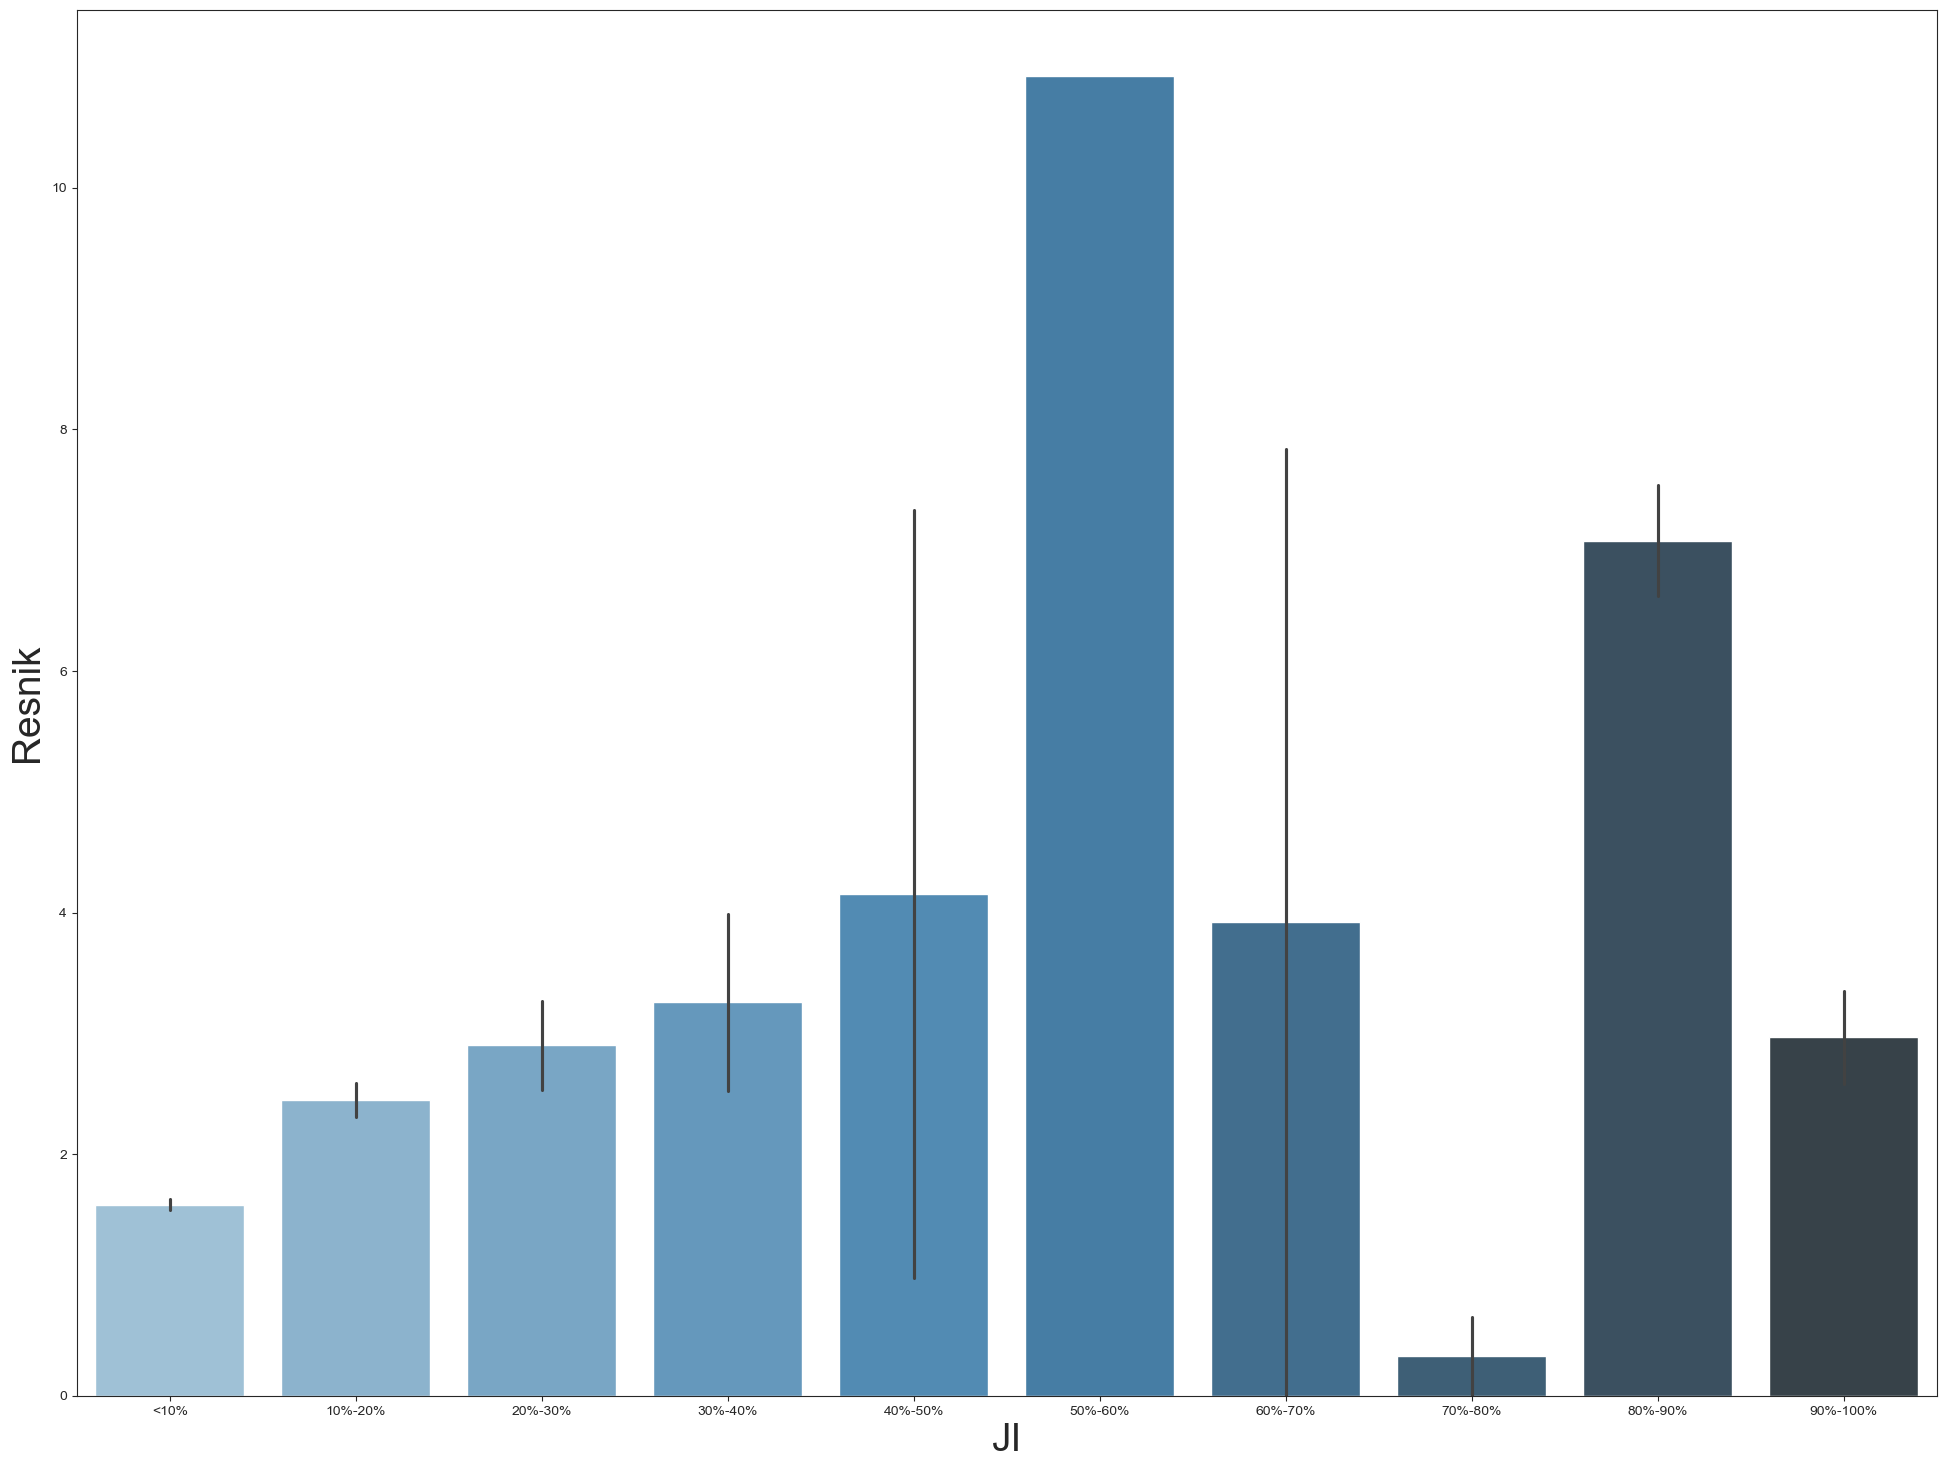

In [39]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(24, 18))
ax = sns.barplot(x="JI", y="Resnik", data=Resnik_JI_df,errorbar='se',
                 palette="Blues_d")
#ax.set_yscale("log")
ax.set_ylabel("Resnik",fontsize=28)
ax.set_xlabel("JI",fontsize=28)
plt.savefig('Figures/Resnik_JI_Grouped_Correlation_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

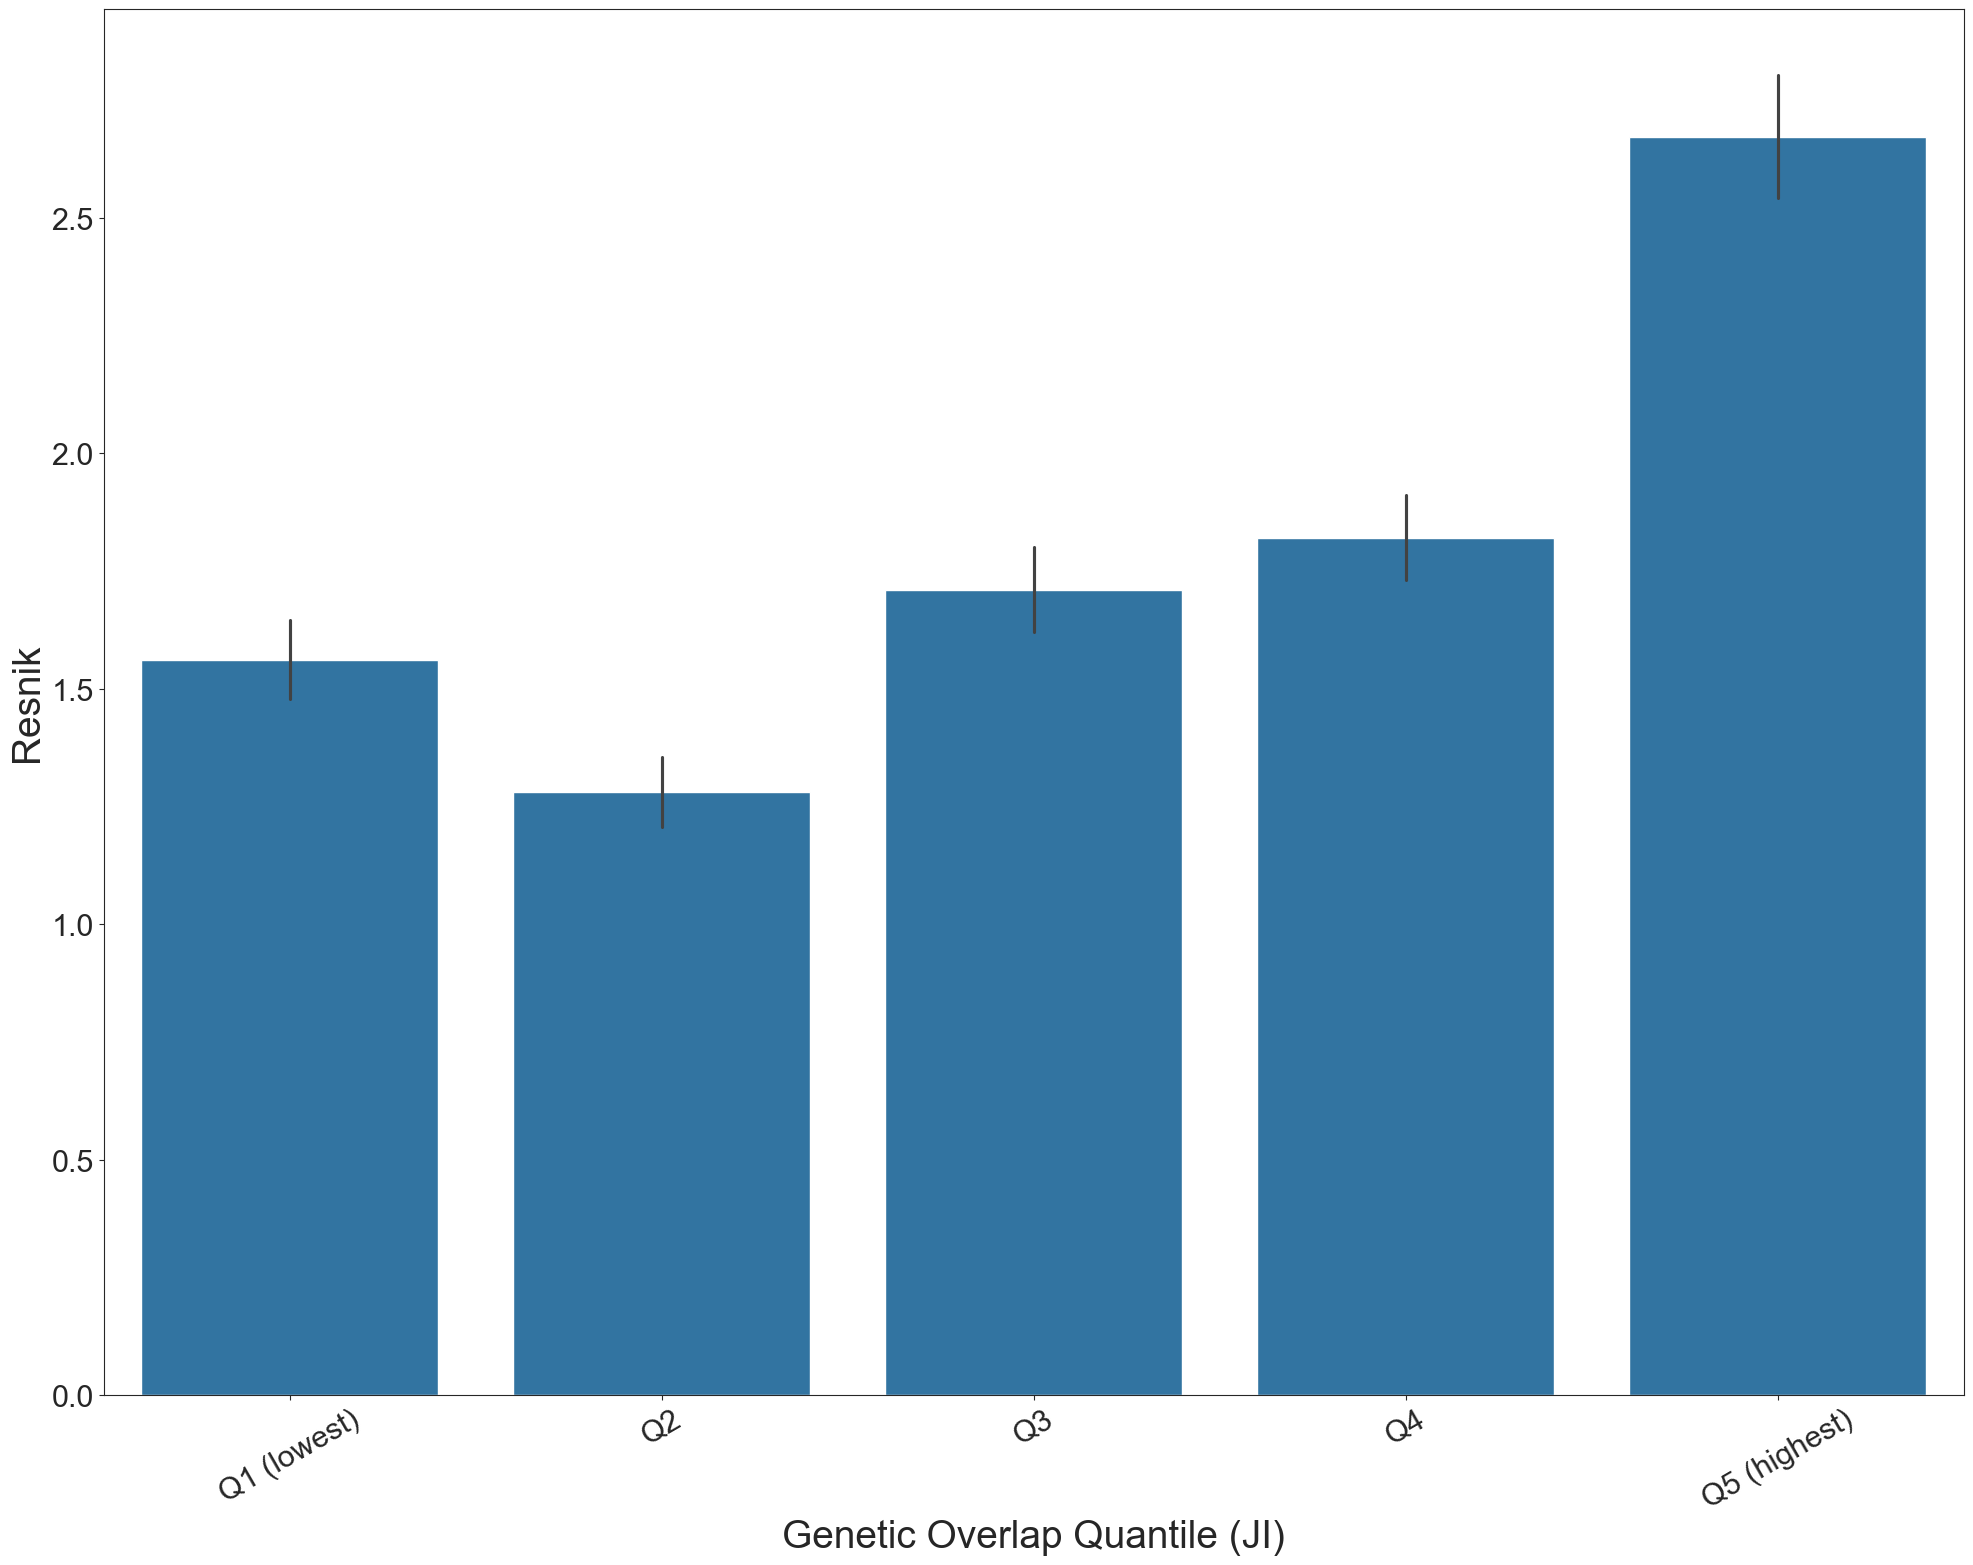

In [40]:
pairs = []
for dis_pair, ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    resnik = G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair]
    pairs.append((ji, resnik))

Resnik_JI_df = pd.DataFrame(pairs, columns=["JI_raw", "Resnik"])

Resnik_JI_df["JI_bin"] = pd.qcut(
    Resnik_JI_df["JI_raw"],
    q=5,
    labels=[
        "Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"
    ]
)

fig, ax = plt.subplots(figsize=(24, 18))

sns.barplot(
    x="JI_bin",
    y="Resnik",
    data=Resnik_JI_df,
    errorbar='se'
)

ax.set_ylabel("Resnik", fontsize=28)
ax.set_xlabel("Genetic Overlap Quantile (JI)", fontsize=28)

plt.xticks(rotation=30, fontsize=22)
plt.yticks(fontsize=22)

plt.savefig(
    'Figures/Resnik_JI_Grouped_Correlation_equalbins_v2026_official.pdf',
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [63]:

pairs = []
for dis_pair, ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    resnik = G_gene_icd_disp_significant_post_edges_resnik_dict[dis_pair]
    pairs.append((ji, resnik))

Resnik_JI_df = pd.DataFrame(pairs, columns=["JI_raw", "Resnik"])

# -----------------------------
# 2. Compute quantile bins (store edges!)
# -----------------------------
Resnik_JI_df["JI_bin"], bin_edges = pd.qcut(
    Resnik_JI_df["JI_raw"],
    q=5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"],
    retbins=True,
    duplicates="drop"
)

# Deterministic sorting
Resnik_JI_df = Resnik_JI_df.sort_values("JI_raw").reset_index(drop=True)

# -----------------------------
# 3. Add metadata column
# -----------------------------
Resnik_JI_df["metadata"] = None

# Sample size per bin
bin_counts = Resnik_JI_df["JI_bin"].value_counts().sort_index()

metadata_entries = []

# Store bin edges explicitly
for i in range(len(bin_edges) - 1):
    metadata_entries.append(
        f"Bin {i+1} range: {bin_edges[i]} to {bin_edges[i+1]}"
    )

# Store N per bin
for bin_name, count in bin_counts.items():
    metadata_entries.append(f"N_{bin_name}: {count}")

# Convert metadata into dataframe rows
metadata_df = pd.DataFrame({
    "JI_raw": [None]*len(metadata_entries),
    "Resnik": [None]*len(metadata_entries),
    "JI_bin": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

# Combine data + metadata
source_df = pd.concat([Resnik_JI_df, metadata_df], ignore_index=True)


excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig2H", index=False)

print(f"Source data saved to {excel_path}")

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38988/2709997584.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  source_df = pd.concat([Resnik_JI_df, metadata_df], ignore_index=True)
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38988/2709997584.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  source_df = pd.concat([Resnik_JI_df, metadata_df], ignore_index=True)


Source data saved to output/SourceData.xlsx


In [41]:
#Let's check now whether we have a similar trend between the genetic and the heritability



G_gene_icd_disp_significant_post_edges_genetic_overlap_dict = {}
G_gene_icd_disp_significant_post_edges_heritability_dict = {}

for e in G_gene_icd_disp_significant_post_edges:
    if (e[0],e[1]) in ICD_heritability.keys():
        G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[e[0],e[1]] = overlap_jaccard(allsources_icd_gene_dict_unified[e[0]],allsources_icd_gene_dict_unified[e[1]])
        G_gene_icd_disp_significant_post_edges_heritability_dict[e[0],e[1]] = ICD_heritability[(e[0],e[1])]
    elif (e[1],e[0]) in ICD_heritability.keys():
        G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[e[0],e[1]] = overlap_jaccard(allsources_icd_gene_dict_unified[e[0]],allsources_icd_gene_dict_unified[e[1]])
        G_gene_icd_disp_significant_post_edges_heritability_dict[e[0],e[1]] = ICD_heritability[(e[1],e[0])]


In [42]:
print(len(G_gene_icd_disp_significant_post_edges_genetic_overlap_dict)==len(G_gene_icd_disp_significant_post_edges_heritability_dict))
print(len(G_gene_icd_disp_significant_post_edges_genetic_overlap_dict))

True
933


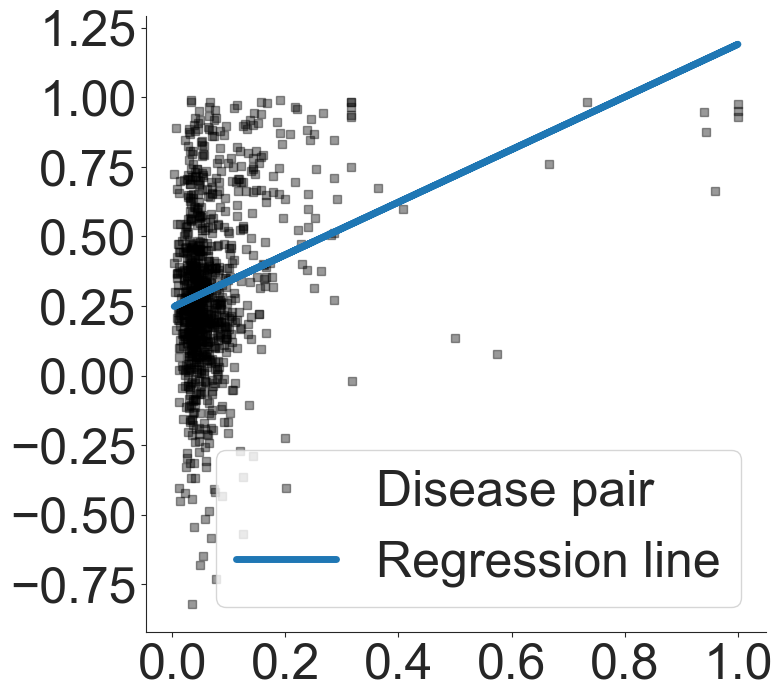

In [50]:
from matplotlib.pyplot import figure
import scipy  
from scipy import stats
fig, ax = plt.subplots(figsize=(8,8))

G_gene_icd_ji_list = []
G_gene_icd_heritability_list = []

for dispair,ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    G_gene_icd_ji_list.append(ji)
    G_gene_icd_heritability_list.append(G_gene_icd_disp_significant_post_edges_heritability_dict[dispair])
    


slope, intercept, r, p, stderr = scipy.stats.linregress(G_gene_icd_ji_list, G_gene_icd_heritability_list)

ax.plot(G_gene_icd_ji_list,G_gene_icd_heritability_list, linewidth=0, marker='s', c='k',label='Disease pair', alpha=0.4)
y=[]
for i in G_gene_icd_ji_list:
    g=(intercept + slope * i)
    y.append(g)
line = "Regression line" 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.plot(G_gene_icd_ji_list, y, label=line,linewidth=5)
plt.xticks(fontsize=36) 
plt.yticks(fontsize=36) 
ax.legend(facecolor='white',fontsize=36)


#plt.savefig('Figures/JI_Heritability_Correlation_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

plt.show()

In [51]:

G_gene_icd_ji_list = []
G_gene_icd_heritability_list = []

for dispair, ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    G_gene_icd_ji_list.append(ji)
    G_gene_icd_heritability_list.append(
        G_gene_icd_disp_significant_post_edges_heritability_dict[dispair]
    )

slope, intercept, r, p, stderr = stats.linregress(
    G_gene_icd_ji_list,
    G_gene_icd_heritability_list
)


df_data = pd.DataFrame({
    "jaccard_index": G_gene_icd_ji_list,
    "heritability": G_gene_icd_heritability_list,
    "metadata": None
})

# Sort for deterministic reproducibility
df_data = df_data.sort_values("jaccard_index").reset_index(drop=True)

# -----------------------------
# 4. Add regression metadata
# -----------------------------
df_metadata = pd.DataFrame({
    "jaccard_index": [None]*6,
    "heritability": [None]*6,
    "metadata": [
        f"Slope: {slope}",
        f"Intercept: {intercept}",
        f"Pearson_r: {r}",
        f"P_value: {p}",
        f"Std_error: {stderr}",
        f"N_pairs: {len(G_gene_icd_ji_list)}"
    ]
})

# Combine data + metadata
source_df = pd.concat([df_data, df_metadata], ignore_index=True)

# -----------------------------
# 5. Save single sheet
# -----------------------------

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig2C", index=False)

print(f"Source data saved to {excel_path}")

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_38988/287209522.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  source_df = pd.concat([df_data, df_metadata], ignore_index=True)


Source data saved to output/SourceData.xlsx


In [44]:
import scipy  
from scipy import stats
print(scipy.stats.pearsonr(G_gene_icd_ji_list,G_gene_icd_heritability_list))  # Pearson's r
print(scipy.stats.spearmanr(G_gene_icd_ji_list,G_gene_icd_heritability_list)) # Spearman's rho


PearsonRResult(statistic=0.2999412081065662, pvalue=7.539260777333785e-21)
SignificanceResult(statistic=0.20677354248860158, pvalue=1.8121146371919607e-10)


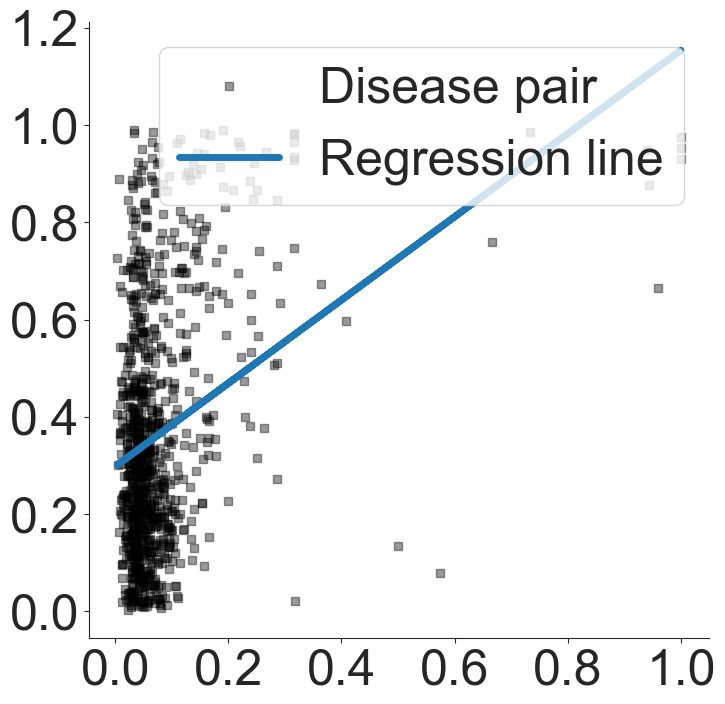

In [45]:
#Let's take only the absolute number of correlation because we are not taking into account the direction of genetic
#similarity
from matplotlib.pyplot import figure
import scipy  
from scipy import stats
fig, ax = plt.subplots(figsize=(8,8))

G_gene_icd_ji_list = []
G_gene_icd_heritability_list = []

for dispair,ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    G_gene_icd_ji_list.append(ji)
    G_gene_icd_heritability_list.append(np.abs(G_gene_icd_disp_significant_post_edges_heritability_dict[dispair]))
    


slope, intercept, r, p, stderr = scipy.stats.linregress(G_gene_icd_ji_list, G_gene_icd_heritability_list)

ax.plot(G_gene_icd_ji_list,G_gene_icd_heritability_list, linewidth=0, marker='s', c='k',label='Disease pair', alpha=0.4)
y=[]
for i in G_gene_icd_ji_list:
    g=(intercept + slope * i)
    y.append(g)
line = "Regression line" 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.plot(G_gene_icd_ji_list, y, label=line,linewidth=5)
plt.xticks(fontsize=36) 
plt.yticks(fontsize=36) 
ax.legend(facecolor='white',fontsize=36)

plt.savefig('Figures/JI_Heritability_Correlation_absolute_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

plt.show()

In [46]:
import scipy  
from scipy import stats
print(scipy.stats.pearsonr(G_gene_icd_ji_list,G_gene_icd_heritability_list))  # Pearson's r
print(scipy.stats.spearmanr(G_gene_icd_ji_list,G_gene_icd_heritability_list)) # Spearman's rho



PearsonRResult(statistic=0.3315524216063218, pvalue=2.242504033531209e-25)
SignificanceResult(statistic=0.21134296223684523, pvalue=7.001844384735559e-11)


In [47]:
#Let's print some examples
for dispair,ji in G_gene_icd_disp_significant_post_edges_genetic_overlap_dict.items():
    if ji>0.6 and G_gene_icd_disp_significant_post_edges_heritability_dict[dispair]>0.6:
        print(dispair)
        

('M06', 'M05')
('E14', 'E13')
('F39', 'F30')
('F13', 'F15')
('F13', 'F19')
('F15', 'F19')
('F70', 'F79')
('K45', 'K46')


In [48]:
G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[('K45', 'K46')]

0.96

In [49]:
G_gene_icd_disp_significant_post_edges_heritability_dict[('K45', 'K46')]

0.665

In [53]:
G_gene_icd_disp_significant_post_edges_genetic_overlap_dict[('F39', 'F30')]

0.9433962264150944

In [54]:
G_gene_icd_disp_significant_post_edges_heritability_dict[('F39', 'F30')]

0.877